# Probit model analysis — numrisk risky choice
**Main model:** `2rem1`, symbolic format  
Formula: `chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)`  
Subjects removed: 32, 40, 45, 46, 50

---

## Hypothesis framework

The three competing accounts of dyscalculia-related risk behaviour make distinct predictions  
for two probit parameters — **gamma** (decision noise/precision) and **indifference point** (risk preference):

| Hypothesis | Predicted signature | Ruled out by |
|---|---|---|
| **H1a** — absolute noise: dysc. representations are globally noisier | overall ↑ gamma in dysc. | no group difference in gamma |
| **H2** — geometry: dysc. process the numerosity ratio less linearly across magnitudes | gamma × stake-size × group | no SS×gamma×group interaction |
| **H1b** — asymmetric attention/noise: dysc. weight safe vs risky option differently, especially at higher magnitudes | ind_point × stake-size × group, *without* SS×gamma×group | — this is what we find |

**Key probit results:**
- No overall gamma group effect (p_bayes ≈ 0.267) → rules out **H1a**
- No SS×gamma×group interaction → rules out **H2**
- SS×ind_point×group interaction (p_bayes ≈ 0.979) → consistent with **H1b**

---

**Risk preference parameter: indifference point**  
`ind_point = -intercept / gamma`  (log-ratio space: `log(n_risky/n_safe)` at P(risky)=0.5)  
Risk-neutral value: `−log(0.55) ≈ 0.598`  
Values **above** 0.598 → risk averse | Values **below** 0.598 → risk seeking

**Structure:**
1. Setup & data  
2. Load trace  
3. Group-level posteriors  
4. Key paper figures — testing H1a, H2, H1b  
   - 4a. ind_point × stake size (both groups)  
   - 4b. Posterior: ind_point × SS and ind_point × SS × group (H1b)  
   - 4c. Posterior: gamma × SS and gamma × SS × group (H2)  
   - 4d. All regressors overview (H1a + sanity check)  
   - 4e. **Main evidence figure** (schematic + data)  
5. Subject-wise ind_point ~ stake-size slopes  
6. Posterior predictive check  
7. Results summary

### Understand indifference point/RNP in terms of probit model & relation to cumulative density function parameters
x = indifference point (where prop. chose risky = 1/2)
$$ 
\frac{1}{2} = \frac{1}{1+e^{\beta_0 - \beta_1*x}} = = \frac{1}{1+e^{\frac{x-\mu}{\sigma}}} 
$$

$$
  1 = e^{\beta_0 - \beta_1*x} \\
  0 = \beta_0 - \beta_1*x \\
  \beta_0  =\beta_1 *x \\
  x = - \frac{\beta_0}{\beta_1} = indifference Point = log(\frac{1}{RNP}) 
$$

$$   RNP = \pi = e^{-\frac{\beta_0}{\beta_0}} $$


So the parameters of the probit model `chose_risky ~ intercept + gamma * x` are a reparameterization of the cumulative density function (\mu, \sigma)... ?

$$ 
    \beta_0 + \beta_1 * x = \frac{x-\mu}{\sigma} \\
    \beta_1 = \frac{1}{\sigma}  \\
    \beta_0 = -\frac{\mu}{\sigma} \\
    \mu = indPoint = -{\beta_0 } * {\sigma} 
    
$$

what we fit it $\beta_0$ + $\beta_1$, but $\mu$ is the real intercept that represents the RNP (or better said, $\frac{1}{RNP}$)

## 1. Setup

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os.path as op
import os
from itertools import product
import bambi
import arviz as az

# ── paths
bids_folder      = '/Users/mrenke/data/ds-dnumrisk'
target_folder    = op.join(bids_folder, 'derivatives', 'cogmodels_risk')
plot_folder      = op.join(bids_folder, 'plots_and_ims', 'behavior_risk')
phenotype_folder = op.join(bids_folder, 'derivatives', 'phenotype')
os.makedirs(plot_folder, exist_ok=True)
os.makedirs(phenotype_folder, exist_ok=True)

import sys
sys.path.insert(0, op.dirname(op.abspath('__file__')))
from utils import get_data, extract_rnp_precision
from utils_03 import format_bambi_ppc, plot_ppc

# ── model config
MODEL_LABEL = '2rem1'
FORMAT      = 'symbolic'
SUBS_REMOVE = [32, 40, 45, 46, 50]
IND_NEUTRAL = - np.log( 0.55)  # ≈ 0.598 — risk-neutral indifference point - defined below where indP is calculated from the probit model intercept and gamma parameters
GROUP_COLORS = {'Control': '#4C72B0', 'Dyscalculia': '#DD8452'}

# ── load & filter data
df_full = get_data(bids_folder)
df_full['x'] = df_full['log(risky/safe)']
df_fil  = df_full.loc[~df_full.index.get_level_values('subject').isin(SUBS_REMOVE)]
data    = df_fil.xs(FORMAT, level='format')

group_list = (df_full.reset_index()
              .drop_duplicates(subset=['subject', 'group'])[['subject', 'group']]
              .set_index('subject'))

# ── rebuild bambi model (needed for predictions / PPC — no re-fitting)
model = bambi.Model(
    'chose_risky ~ x + x*group*n_safe + (x*n_safe|subject)',
    link='probit', family='bernoulli', data=data.reset_index()
)
print(f'Data: {data.index.unique("subject").shape[0]} subjects, format={FORMAT}')
print(f'Risk-neutral indifference point: {IND_NEUTRAL:.3f}')

number of subjects in dataframe: 66
Int64Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
            18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
            35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
            52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
           dtype='int64', name='subject')
Data: 61 subjects, format=symbolic
Risk-neutral indifference point: 0.598


## 2. Load trace

In [4]:
trace_path = op.join(target_folder, f'probit_model-{MODEL_LABEL}_format-{FORMAT}_trace.netcdf')
traces = az.from_netcdf(trace_path)
print('Loaded:', trace_path)
print(traces.posterior)

Loaded: /Users/mrenke/data/ds-dnumrisk/derivatives/cogmodels_risk/probit_model-2rem1_format-symbolic_trace.netcdf
<xarray.Dataset>
Dimensions:                 (chain: 4, draw: 1000, subject__factor_dim: 61)
Coordinates:
  * chain                   (chain) int64 0 1 2 3
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * subject__factor_dim     (subject__factor_dim) object '1' '2' ... '65' '66'
Data variables: (12/16)
    Intercept               (chain, draw) float64 ...
    x                       (chain, draw) float64 ...
    group                   (chain, draw) float64 ...
    x:group                 (chain, draw) float64 ...
    n_safe                  (chain, draw) float64 ...
    x:n_safe                (chain, draw) float64 ...
    ...                      ...
    n_safe|subject_sigma    (chain, draw) float64 ...
    x:n_safe|subject_sigma  (chain, draw) float64 ...
    1|subject               (chain, draw, subject__factor_dim) float64 ...
    x|

## 3. Group-level posteriors

Extract group-level **gamma** (decision noise) and **indifference point** per stake size,  
the two parameters needed to test H1a, H2, and H1b.

`ind_point = -intercept / gamma`  — the log-ratio at which P(chose risky) = 0.5.

In [5]:
intercept_g, gamma_g = extract_rnp_precision(
    traces, model, data, format=False, group_level=True
)

# indifference point = 1/RNP = exp(-intercept / gamma)
ind_g = (-intercept_g / gamma_g)
#IND_NEUTRAL = - np.log(0.55)  # ≈ 1.818 — risk-neutral indifference point

#ind_g = - gamma_g/intercept_g

# stack chain/draw into long format
ind_long       = ind_g.stack([1, 2]).rename(columns={'chose_risky_mean': 'ind_point'})
gamma_long     = gamma_g.stack([1, 2]).rename(columns={'chose_risky_mean': 'gamma'})
intercept_long = intercept_g.stack([1, 2]).rename(columns={'chose_risky_mean': 'intercept'})
print(ind_long.head())

                                 ind_point
subject n_safe group chain draw           
13      7.0    1     0     0      1.114281
                           1      1.128111
                           2      1.105184
                           3      1.110072
                           4      1.113522


### 3a. Quick overview — violin plots per stake size

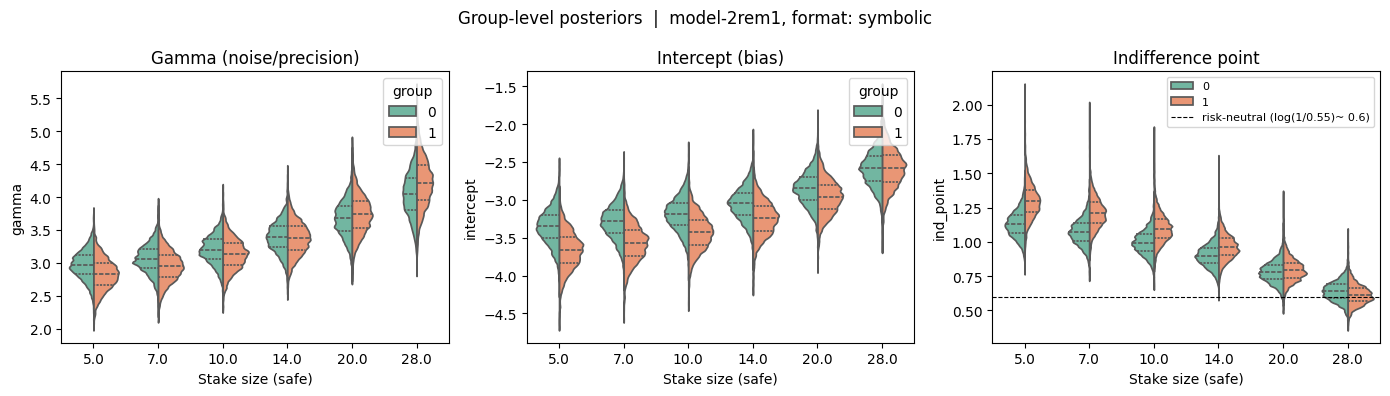

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for ax, df_p, col, label, hline in zip(
    axs,
    [gamma_long,  intercept_long,  ind_long],
    ['gamma',     'intercept',     'ind_point'],
    ['Gamma (noise/precision)', 'Intercept (bias)', 'Indifference point'],
    [None,        None,            IND_NEUTRAL]
):
    sns.violinplot(data=df_p.reset_index(), x='n_safe', y=col,
                   hue='group', split=True, inner='quart', ax=ax, palette='Set2')
    
    if hline is not None:
        ax.axhline(hline, color='k', ls='--', lw=0.8, label=f'risk-neutral (log(1/0.55)~ 0.6)')
        ax.legend(fontsize=8)
    ax.set_title(label)
    ax.set_xlabel('Stake size (safe)')

fig.suptitle(f'Group-level posteriors  |  model-{MODEL_LABEL}, format: {FORMAT}')
plt.tight_layout()
plt.savefig(op.join(plot_folder,
    f'probit_model-{MODEL_LABEL}_format-{FORMAT}_group-posteriors.pdf'), bbox_inches='tight')
plt.show()

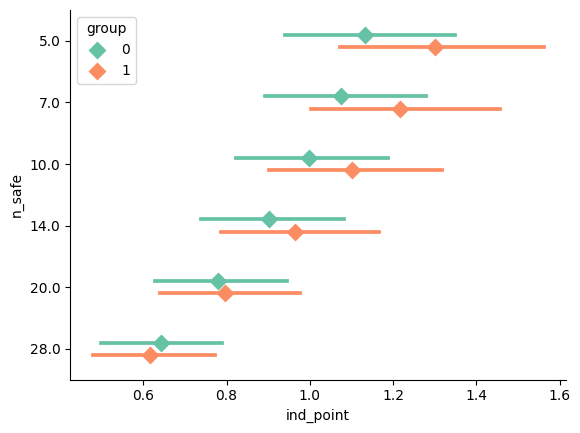

In [21]:
sns.pointplot(data=ind_long.reset_index(), y='n_safe', x='ind_point', hue='group', 
              palette='Set2',errorbar=("pi", 95),orient='h', dodge=0.2,linestyle='', marker="D")
sns.despine()

In [52]:
ind_long['RNP'] = np.exp(-ind_long['ind_point'])


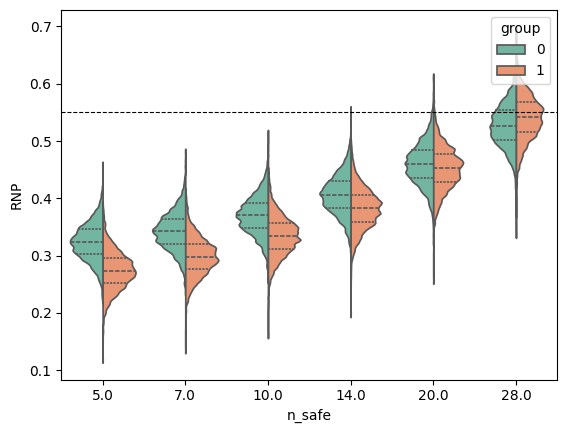

In [50]:
sns.violinplot(data=ind_long.reset_index(), x='n_safe', y='RNP',
                hue='group', split=True, inner='quart', palette='Set2')
plt.axhline(0.55, color='k', ls='--', lw=0.8, label=f'risk-neutral (RNP={1/0.55:.2f})')

## 4. Key paper figures

The figures below test the three hypotheses in sequence.  
Sections 4b–4d each probe one hypothesis; 4e combines them into the main evidence figure.

---

### 4a. Indifference point × stake size — both groups

Establishes the basic behavioural pattern: how risk preference shifts with stake size,  
and whether the two groups track the same trajectory or diverge.

In [9]:
ind_summary = (
    ind_long.reset_index()
    .groupby(['group', 'n_safe'])['ind_point']
    .agg(
        mean='mean',
        hdi_lo=lambda x: az.hdi(x.values)[0],
        hdi_hi=lambda x: az.hdi(x.values)[1]
    )
    .reset_index()
)
ind_summary['group_label'] = ind_summary['group'].map({0: 'Control', 1: 'Dyscalculia'})
ind_summary

,group,n_safe,mean,hdi_lo,hdi_hi,group_label
0,0,5.0,1.131898,0.935244,1.318646,Control
1,0,7.0,1.075335,0.901454,1.269791,Control
2,0,10.0,0.996903,0.831481,1.180916,Control
3,0,14.0,0.902662,0.751121,1.079740,Control
4,0,20.0,0.779497,0.628996,0.933475,Control
5,0,28.0,0.641771,0.509668,0.786378,Control
6,1,5.0,1.301418,1.079241,1.541421,Dyscalculia
7,1,7.0,1.215721,1.013597,1.445085,Dyscalculia
8,1,10.0,1.099995,0.920919,1.315782,Dyscalculia
9,1,14.0,0.965463,0.789917,1.149106,Dyscalculia


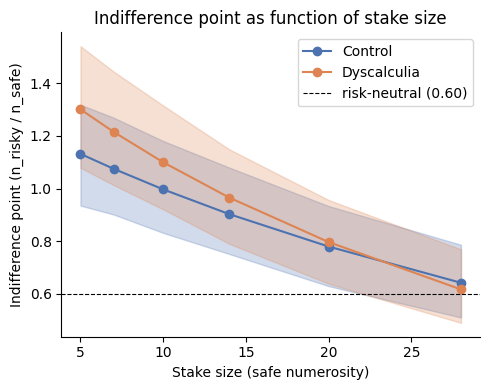

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

for grp_label, grp_df in ind_summary.groupby('group_label'):
    c = GROUP_COLORS[grp_label]
    ax.fill_between(grp_df['n_safe'], grp_df['hdi_lo'], grp_df['hdi_hi'],
                    alpha=0.25, color=c)
    ax.plot(grp_df['n_safe'], grp_df['mean'], marker='o', label=grp_label, color=c)

ax.axhline(IND_NEUTRAL, color='k', ls='--', lw=0.8, label=f'risk-neutral ({IND_NEUTRAL:.2f})')
ax.set_xlabel('Stake size (safe numerosity)')
ax.set_ylabel('Indifference point (n_risky / n_safe)')
ax.set_title('Indifference point as function of stake size')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(op.join(plot_folder,
    f'PAPER_probit_indpoint-by-stake-size_model-{MODEL_LABEL}_format-{FORMAT}.pdf'), bbox_inches='tight')
plt.show()

### 4b. ind_point × stake-size and ind_point × stake-size × group — testing H1b

**H1b predicts:** ind_point changes with stake size (general effect), *and* that modulation  
is stronger in dyscalculia (group × SS interaction), *without* a corresponding gamma effect.

For each posterior sample, a line is fit through `ind_point ~ stake_size` per group.  
The general effect (average slope) and the group difference (Dysc − Control) are then extracted.

In [11]:
n_chains = ind_long.index.unique('chain').values
n_draws  = ind_long.index.unique('draw').values
index    = pd.MultiIndex.from_product([n_chains, n_draws], names=['chain', 'draw'])

df_slopes = pd.DataFrame(index=index,
                          columns=['slope_control', 'slope_dyscalc'],
                          dtype=float)

for chain, draw in product(n_chains, n_draws):
    sample = ind_long.xs(chain, level='chain').xs(draw, level='draw').reset_index()
    for grp_idx, grp_name in [(0, 'control'), (1, 'dyscalc')]:
        tmp   = sample[sample['group'] == grp_idx]
        A     = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
        slope, _ = np.linalg.lstsq(A, tmp['ind_point'], rcond=None)[0]
        df_slopes.loc[(chain, draw), f'slope_{grp_name}'] = slope

# general effect = average across both groups; group difference = Dysc − Control
df_slopes['slope_general'] = (df_slopes['slope_control'] + df_slopes['slope_dyscalc']) / 2
df_slopes['slope_diff']    = df_slopes['slope_dyscalc'] - df_slopes['slope_control']

for col in ['slope_general', 'slope_diff']:
    p_neg = np.mean(df_slopes[col] < 0)
    print(f'{col}: mean={df_slopes[col].mean():.5f}, '
          f'95%CI={np.round(np.percentile(df_slopes[col], [2.5, 97.5]), 5)}, '
          f'p_bayes(<0)={p_neg:.3f}')

slope_general: mean=-0.02547, 95%CI=[-0.0298 -0.0216], p_bayes(<0)=1.000
slope_diff: mean=-0.00839, 95%CI=[-0.01661 -0.00077], p_bayes(<0)=0.983


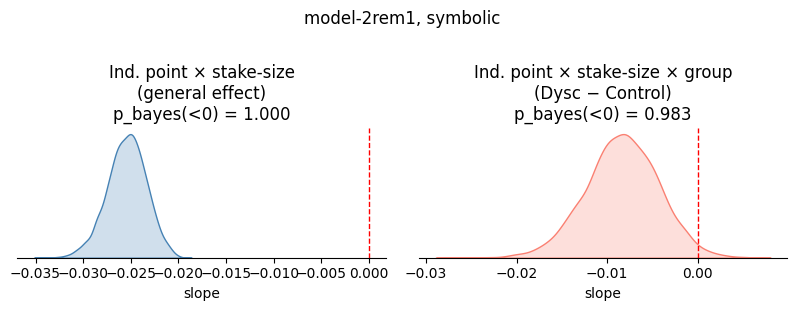

In [12]:
panels_4b = {
    'slope_general': ('Ind. point × stake-size\n(general effect)', 'steelblue'),
    'slope_diff':    ('Ind. point × stake-size × group\n(Dysc − Control)', 'salmon'),
}

fig, axs = plt.subplots(1, 2, figsize=(8, 3))

for ax, (col, (title, color)) in zip(axs, panels_4b.items()):
    p = np.mean(df_slopes[col] < 0)
    sns.kdeplot(df_slopes[col], fill=True, ax=ax, color=color)
    ax.axvline(0, color='r', ls='--', lw=1)
    ax.set_title(f'{title}\np_bayes(<0) = {p:.3f}')
    ax.set(yticks=[], ylabel='', xlabel='slope')
    sns.despine(ax=ax, left=True)

fig.suptitle(f'model-{MODEL_LABEL}, {FORMAT}', y=1.02)
plt.tight_layout()
plt.savefig(op.join(plot_folder,
    f'PAPER_probit_indpoint-SS-slope-posteriors_model-{MODEL_LABEL}_format-{FORMAT}.pdf'),
    bbox_inches='tight')
plt.show()

### 4c. gamma × stake-size and gamma × stake-size × group — testing H2

**H2 predicts:** if dyscalculia reflects a non-linear geometry of numerosity processing,  
decision noise (gamma) should change with stake size *differently* across groups.

- `x:n_safe` — does gamma change with stake size overall? (establishes linearity baseline)  
- `x:group:n_safe` — does that change *differ between groups*? (the H2 test)

A null result here, combined with a positive result in 4b, is the key double dissociation  
that supports H1b over H2.

*(The overall `x:group` gamma effect — H1a test — is in the 4d overview below.)*

x:n_safe: mean=0.0468, 95%CI=[0.02207692 0.07237131], p_bayes(>0)=1.000
x:group:n_safe: mean=0.0137, 95%CI=[-0.02427995  0.04951366], p_bayes(>0)=0.770


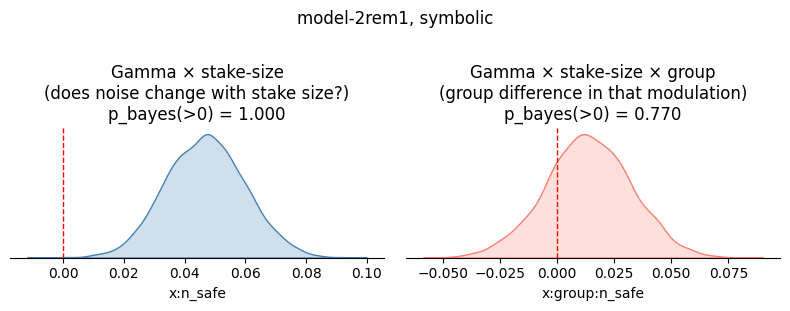

In [13]:
panels_4c = {
    'x:n_safe':       ('Gamma × stake-size\n(does noise change with stake size?)', 'steelblue'),
    'x:group:n_safe': ('Gamma × stake-size × group\n(group difference in that modulation)', 'salmon'),
}

fig, axs = plt.subplots(1, 2, figsize=(8, 3))

for ax, (var, (title, color)) in zip(axs, panels_4c.items()):
    vals = traces.posterior[var].to_dataframe()[var]
    p    = np.mean(vals > 0)
    sns.kdeplot(vals, fill=True, ax=ax, color=color)
    ax.axvline(0, color='r', ls='--', lw=1)
    ax.set_title(f'{title}\np_bayes(>0) = {p:.3f}')
    ax.set(yticks=[], ylabel='', xlabel=var)
    sns.despine(ax=ax, left=True)
    print(f'{var}: mean={vals.mean():.4f}, 95%CI={np.percentile(vals, [2.5, 97.5])}, p_bayes(>0)={p:.3f}')

fig.suptitle(f'model-{MODEL_LABEL}, {FORMAT}', y=1.02)
plt.tight_layout()
plt.savefig(op.join(plot_folder,
    f'PAPER_probit_gamma-SS-effects_model-{MODEL_LABEL}.pdf'), bbox_inches='tight')
plt.show()

### 4d. All group-level regressors — full overview (includes H1a test)

Posterior distributions for all population-level terms.  
The `x:group` term here is the **H1a test** — an overall group difference in gamma.

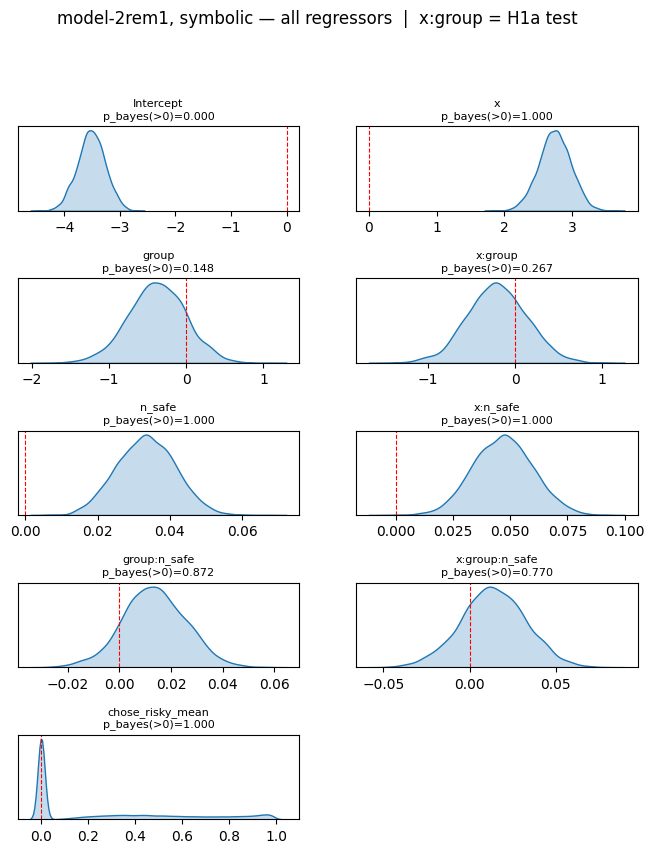

In [14]:
variable_names = [v for v in traces.posterior.data_vars if 'subject' not in v]
n_vars = len(variable_names)
n_cols = 2
n_rows = (n_vars + 1) // n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=(8, n_rows * 1.8))
axs = axs.flatten()

for i, var in enumerate(variable_names):
    vals = traces.posterior[var].values.flatten()
    p    = np.mean(vals > 0)
    sns.kdeplot(vals, fill=True, ax=axs[i])
    axs[i].axvline(0, color='r', ls='--', lw=0.8)
    axs[i].set_title(f'{var}\np_bayes(>0)={p:.3f}', fontsize=8)
    axs[i].set(yticks=[], ylabel='')

for ax in axs[n_vars:]:
    ax.set_visible(False)

fig.suptitle(f'model-{MODEL_LABEL}, {FORMAT} — all regressors  |  x:group = H1a test', y=1.01)
fig.subplots_adjust(hspace=0.8, wspace=0.2)
plt.savefig(op.join(plot_folder,
    f'probit_model-{MODEL_LABEL}_format-{FORMAT}_all-regressors.pdf'), bbox_inches='tight')
plt.show()

### 4e. Main evidence figure

Combines the hypothesis schematics with the actual data in a single paper-ready figure.

**Top row — what each hypothesis predicts** (cartoon, gamma and ind_point per group):  
- H1a: gamma shifted up for dyscalculia overall; ind_point unaffected  
- H2: gamma slope differs across groups; ind_point follows  
- H1b: gamma identical across groups; ind_point slope differs ← what we find  

**Bottom row — actual posteriors (symbolic, 5 subs removed):**  
- Left: gamma × stake-size, both groups (establishes the linearity baseline; no group split → H2 ruled out)  
- Right: ind_point × stake-size × group (the key H1b finding)

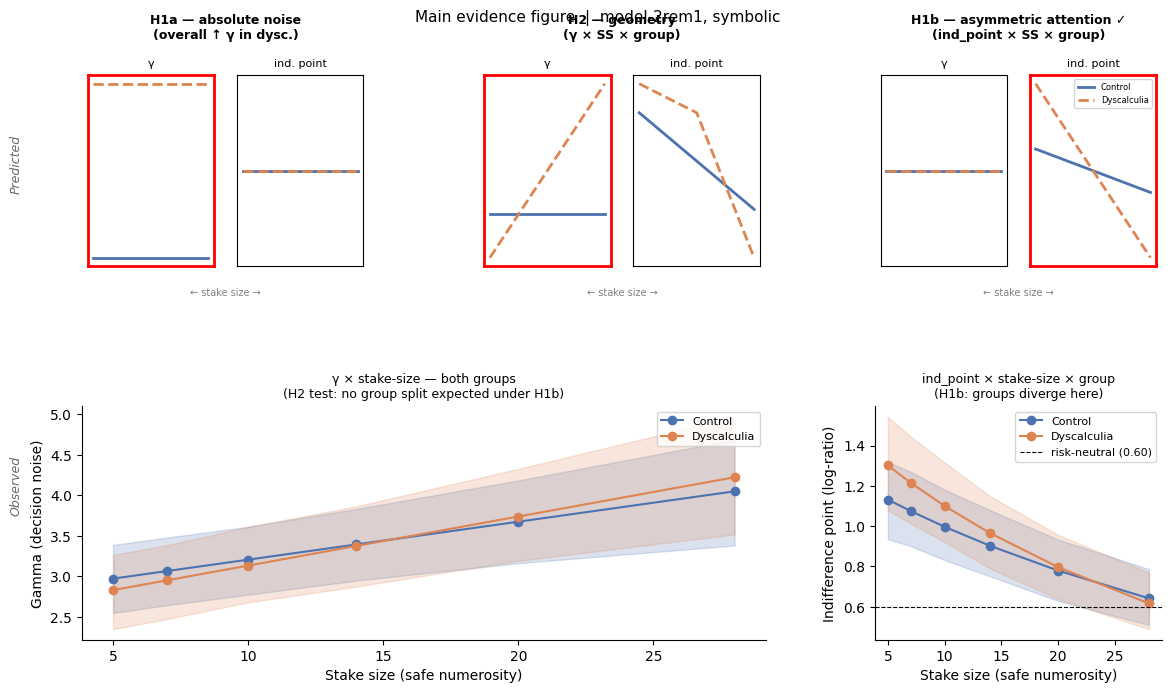

Saved to /Users/mrenke/data/ds-dnumrisk/plots_and_ims/behavior_risk


In [ ]:
import matplotlib.gridspec as gridspec

C  = GROUP_COLORS['Control']
D  = GROUP_COLORS['Dyscalculia']
ss = np.array([1, 2, 3])   # fake stake-size axis for schematics

fig = plt.figure(figsize=(12, 7))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38,
                        top=0.93, bottom=0.08, left=0.07, right=0.97)

# ── helpers ───────────────────────────────────────────────────────────────
def schematic_ax(ax, title, gamma_c, gamma_d, ind_c, ind_d, highlight_gamma=False, highlight_ind=False):
    """Draw two mini panels (gamma, ind_point) side by side inside one axes using inset_axes."""
    ax.axis('off')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)

    # left inset: gamma
    ax_g = ax.inset_axes([0.02, 0.05, 0.44, 0.82])
    ax_g.plot(ss, gamma_c, color=C, lw=2)
    ax_g.plot(ss, gamma_d, color=D, lw=2, ls='--')
    ax_g.set(xticks=[], yticks=[], xlabel='')
    ax_g.set_title('γ', fontsize=8)
    if highlight_gamma:
        for spine in ax_g.spines.values():
            spine.set(edgecolor='red', linewidth=2)

    # right inset: ind_point
    ax_i = ax.inset_axes([0.54, 0.05, 0.44, 0.82])
    ax_i.plot(ss, ind_c, color=C, lw=2, label='Control')
    ax_i.plot(ss, ind_d, color=D, lw=2, ls='--', label='Dyscalculia')
    ax_i.set(xticks=[], yticks=[])
    ax_i.set_title('ind. point', fontsize=8)
    if highlight_ind:
        for spine in ax_i.spines.values():
            spine.set(edgecolor='red', linewidth=2)
    return ax_g, ax_i

# ── schematic: H1a ────────────────────────────────────────────────────────
ax_h1a = fig.add_subplot(gs[0, 0])
schematic_ax(
    ax_h1a, 'H1a — absolute noise\n(overall ↑ γ in dysc.)',
    gamma_c = [3, 3, 3],        gamma_d = [4.5, 4.5, 4.5],   # dysc. shifted up overall
    ind_c   = [2, 2, 2],        ind_d   = [2, 2, 2],          # ind_point unaffected
    highlight_gamma=True,       highlight_ind=False
)

# ── schematic: H2 ─────────────────────────────────────────────────────────
ax_h2 = fig.add_subplot(gs[0, 1])
schematic_ax(
    ax_h2, 'H2 — geometry\n(γ × SS × group)',
    gamma_c = [3, 3, 3],        gamma_d = [2.5, 3.5, 4.5],   # dysc. has steeper gamma slope
    ind_c   = [2.5, 2, 1.5],    ind_d   = [2.8, 2.5, 1.0],   # ind_point also shifts
    highlight_gamma=True,       highlight_ind=False
)

# ── schematic: H1b (what we find) ─────────────────────────────────────────
ax_h1b = fig.add_subplot(gs[0, 2])
ag, ai = schematic_ax(
    ax_h1b, 'H1b — asymmetric attention ✓\n(ind_point × SS × group)',
    gamma_c = [3, 3, 3],        gamma_d = [3, 3, 3],          # gamma identical
    ind_c   = [2.2, 2.0, 1.8],  ind_d   = [2.8, 2.0, 1.2],   # ind_point slope differs
    highlight_gamma=False,      highlight_ind=True
)
ai.legend(fontsize=6, loc='upper right')

# ── add stake-size label to schematic column ──────────────────────────────
for ax_s in [ax_h1a, ax_h2, ax_h1b]:
    ax_s.text(0.5, -0.04, '← stake size →', ha='center', va='top',
              transform=ax_s.transAxes, fontsize=7, color='grey')

# ── data panel: gamma × stake-size (both groups) ─────────────────────────
ax_gamma = fig.add_subplot(gs[1, 0:2])

gamma_summary = (
    gamma_long.reset_index()
    .groupby(['group', 'n_safe'])['gamma']
    .agg(mean='mean',
         hdi_lo=lambda x: az.hdi(x.values)[0],
         hdi_hi=lambda x: az.hdi(x.values)[1])
    .reset_index()
)
gamma_summary['group_label'] = gamma_summary['group'].map({0: 'Control', 1: 'Dyscalculia'})

for grp_label, grp_df in gamma_summary.groupby('group_label'):
    c = GROUP_COLORS[grp_label]
    ax_gamma.fill_between(grp_df['n_safe'], grp_df['hdi_lo'], grp_df['hdi_hi'],
                          alpha=0.2, color=c)
    ax_gamma.plot(grp_df['n_safe'], grp_df['mean'], marker='o', color=c, label=grp_label)

ax_gamma.set_xlabel('Stake size (safe numerosity)')
ax_gamma.set_ylabel('Gamma (decision noise)')
ax_gamma.set_title('γ × stake-size — both groups\n(H2 test: no group split expected under H1b)',
                   fontsize=9)
ax_gamma.legend(fontsize=8)
sns.despine(ax=ax_gamma)

# ── data panel: ind_point × stake-size × group ───────────────────────────
ax_ind = fig.add_subplot(gs[1, 2])

for grp_label, grp_df in ind_summary.groupby('group_label'):
    c = GROUP_COLORS[grp_label]
    ax_ind.fill_between(grp_df['n_safe'], grp_df['hdi_lo'], grp_df['hdi_hi'],
                        alpha=0.2, color=c)
    ax_ind.plot(grp_df['n_safe'], grp_df['mean'], marker='o', color=c, label=grp_label)

ax_ind.axhline(IND_NEUTRAL, color='k', ls='--', lw=0.8,
               label=f'risk-neutral ({IND_NEUTRAL:.2f})')
ax_ind.set_xlabel('Stake size (safe numerosity)')
ax_ind.set_ylabel('Indifference point (log-ratio)')
ax_ind.set_title('ind_point × stake-size × group\n(H1b: groups diverge here)',
                 fontsize=9)
ax_ind.legend(fontsize=8)
sns.despine(ax=ax_ind)

# ── row labels ────────────────────────────────────────────────────────────
fig.text(0.01, 0.76, 'Predicted', va='center', rotation=90,
         fontsize=9, color='dimgrey', style='italic')
fig.text(0.01, 0.30, 'Observed', va='center', rotation=90,
         fontsize=9, color='dimgrey', style='italic')

fig.suptitle(f'Main evidence figure  |  model-{MODEL_LABEL}, {FORMAT}', fontsize=11, y=1.2)

plt.savefig(op.join(plot_folder,
    f'PAPER_main-evidence-figure_model-{MODEL_LABEL}_format-{FORMAT}.pdf'),
    bbox_inches='tight')
plt.show()
print('Saved to', plot_folder)

## 5. Subject-wise indifference point ~ stake-size slopes

Extract subject-level indifference point posteriors and fit `ind_point ~ stake_size` per subject.  
MAPs (posterior means) are saved to the phenotype folder for correlation analyses.

In [16]:
intercept_s, gamma_s = extract_rnp_precision(
    traces, model, data, format=False, group_level=False
)

# indifference point per subject: ind_point = -intercept / gamma  (log-ratio space)
ind_s      = (-intercept_s / gamma_s)
ind_s_long = ind_s.stack([1, 2]).rename(columns={'chose_risky_mean': 'ind_point'})
gamma_s_long     = gamma_s.stack([1, 2]).rename(columns={'chose_risky_mean': 'gamma'})
intercept_s_long = intercept_s.stack([1, 2]).rename(columns={'chose_risky_mean': 'intercept'})
print(ind_s_long.head())

                                 ind_point
subject n_safe group chain draw           
13      7.0    1     0     0      1.174708
                           1      1.170925
                           2      1.168211
                           3      1.212952
                           4      1.219479


In [17]:
subjects  = ind_s_long.index.unique('subject').values
n_chains  = ind_s_long.index.unique('chain').values
n_draws   = ind_s_long.index.unique('draw').values
sub_index = pd.MultiIndex.from_product([subjects, n_chains, n_draws],
                                        names=['subject', 'chain', 'draw'])

df_ss = pd.DataFrame(index=sub_index, columns=['ss_slope', 'ss_intercept'], dtype=float)

for chain, draw in product(n_chains, n_draws):
    sample = ind_s_long.xs(chain, level='chain').xs(draw, level='draw').reset_index()
    for sub in subjects:
        tmp = sample[sample['subject'] == sub]
        A   = np.vstack([tmp['n_safe'], np.ones(len(tmp))]).T
        slope, intercept_val = np.linalg.lstsq(A, tmp['ind_point'], rcond=None)[0]
        df_ss.loc[(sub, chain, draw), 'ss_slope']     = slope
        df_ss.loc[(sub, chain, draw), 'ss_intercept'] = intercept_val

print('Done. Computing MAPs...')

maps = (df_ss.groupby('subject').mean()
        .join(group_list)
        .join(gamma_s_long.reset_index().groupby('subject')['gamma'].mean())
        .join(intercept_s_long.reset_index().groupby('subject')['intercept'].mean()))
maps.head()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_27044/4232469187.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_ss.loc[(sub, chain, draw), 'ss_slope']     = slope
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_27044/4232469187.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_ss.loc[(sub, chain, draw), 'ss_intercept'] = intercept_val
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_27044/4232469187.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_ss.loc[(sub, chain, draw), 'ss_slope']     = slope
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_27044/4232469187.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_ss.loc[(sub, chain, draw), 'ss_intercept'] = intercept_val
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_27044/4232469187.py:15: PerformanceWarning: indexing past lexsort depth may impac

Done. Computing MAPs...


,ss_slope,ss_intercept,group,gamma,intercept
subject,,,,,
1,-0.015908,1.232876,0,4.532440,-4.516689
2,-0.056294,2.165345,1,2.371846,-2.928014
3,-0.118882,3.890129,0,2.101541,-3.669082
4,-0.035593,1.727082,1,3.592754,-4.194315
5,-0.031585,1.415766,0,3.394333,-3.124358


Saved MAPs to /Users/mrenke/data/ds-dnumrisk/derivatives/phenotype


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_27044/2286546927.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=maps.reset_index(), x='group', y='ss_slope', jitter=True,


ValueError: The palette dictionary is missing keys: {'0', '1'}

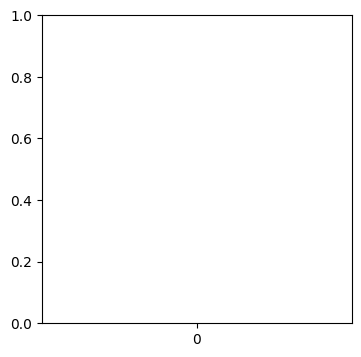

In [18]:
# save MAPs
maps.to_csv(op.join(phenotype_folder,
    f'risk_SS-indpoint-subwise-MAPs_probit-{MODEL_LABEL}_format-{FORMAT}.csv'))
print('Saved MAPs to', phenotype_folder)

# quick group comparison
fig, ax = plt.subplots(figsize=(4, 4))
sns.stripplot(data=maps.reset_index(), x='group', y='ss_slope', jitter=True,
              palette={0: GROUP_COLORS['Control'], 1: GROUP_COLORS['Dyscalculia']},
              ax=ax, size=6, alpha=0.7)
sns.pointplot(data=maps.reset_index(), x='group', y='ss_slope', ax=ax,
              palette={0: GROUP_COLORS['Control'], 1: GROUP_COLORS['Dyscalculia']},
              markers='D', join=True)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticklabels(['Control', 'Dyscalculia'])
ax.set_ylabel('Ind. point ~ stake-size slope (MAP)')
ax.set_title('Subject-wise indifference point ~ stake-size slopes')
sns.despine()
plt.tight_layout()
plt.savefig(op.join(plot_folder,
    f'probit_model-{MODEL_LABEL}_subwise-SS-indpoint-slopes.pdf'), bbox_inches='tight')
plt.show()

## 6. Posterior predictive check

Group-level PPC: how well does the model recover the observed choice curves?

In [ ]:
ppc = format_bambi_ppc(traces, model, data)

for plot_type in [1, 2]:
    fac = plot_ppc(data, ppc, level='group', plot_type=plot_type)
    fac.fig.suptitle(f'PPC — model-{MODEL_LABEL}, {FORMAT}  (plot_type={plot_type})', y=1.02)
    fac.savefig(op.join(plot_folder,
        f'ppc_probit_model-{MODEL_LABEL}_format-{FORMAT}_type-{plot_type}.pdf'),
        bbox_inches='tight')
    plt.show()

## 7. Results summary

### Hypothesis tests

| Hypothesis | Test (probit term) | Result | Conclusion |
|---|---|---|---|
| **H1a** — absolute noise | `x:group` (overall gamma group diff) | p_bayes ≈ 0.267 — null | **H1a ruled out** |
| **H2** — geometry | `x:group:n_safe` (gamma × SS × group) | null | **H2 ruled out** |
| **H1b** — asymmetric attention | `ind_point × SS × group` (slope diff) | p_bayes ≈ 0.979 | **H1b supported** |

### Supporting results

| Effect | p_bayes | Interpretation |
|---|---|---|
| `x:n_safe` — gamma × stake-size (general) | see 4c | Gamma does/doesn't change with SS — establishes geometry baseline |
| ind_point × stake-size (general) | see 4b | Risk preference shifts with stake size in both groups |
| **ind_point × SS × group** | **≈ 0.979** | **Dyscalculia: stronger modulation of risk preference by magnitude** |

### Implication for cognitive model fitting

The double dissociation (SS×ind_point×group **without** SS×gamma×group) guides the cognitive models:
- Group regressors on **prior parameters** (capture the ind_point asymmetry) ✓
- Group regressors on **evidence_sd** (would capture a gamma effect) ✗ — not warranted